# Predicting cheap and spiky power hours in Germany from free ENTSO-E data

**What this is.** A tiny, reproducible model that turns two *free* forecast feeds
(load, wind + solar) into one forward-looking index — **Net-Load Tightness (NLT)** —
and flags the hours most likely to see a **price spike** or **cheap / negative**
prices in the German (DE-LU) day-ahead market. Then it **backtests** those flags
out-of-sample, so the numbers below are earned, not asserted.

**Who it's for.** Anyone modelling DE-LU: traders, battery/EV optimisers, energy-data
folks who currently wrangle ENTSO-E by hand. If it's useful, there's a one-line ask at
the bottom.

**Read the table, not the prose.** The headline is the *precision* (hit-rate when the
signal fires) and the *lift* over the base rate, on data the model never trained on.

> ⚠️ **Honesty banner.** If the cell below prints `SYNTHETIC demo data`, every number and
> chart here is from a **synthetic generator that wires price to net load on purpose** — it
> proves the pipeline runs, and says *nothing* about the real German market. The real
> figures appear only after you fetch ENTSO-E data (`scripts/fetch_data.py`) and set
> `DEMO = False`. Don't publish synthetic numbers as if they were real.

In [1]:
# --- setup: find the package whether run from repo root or notebook/ ---
import sys, pathlib
here = pathlib.Path.cwd()
for base in [here, *here.parents]:
    if (base / "src" / "energy_nlt").is_dir():
        sys.path.insert(0, str(base / "src")); break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from energy_nlt import config as C, features, backtest, synthetic, data as data_mod
from energy_nlt.signal import fit_thresholds, apply_flags, label_events

# Okabe-Ito colours (colourblind-safe): spike = vermillion, cheap = blue.
SPIKE, CHEAP = "#D55E00", "#0072B2"

In [2]:
DEMO = False   # ← set False after: export ENTSOE_API_TOKEN=... && python scripts/fetch_data.py ...

if DEMO:
    hourly, capacity = synthetic.make(years=3.0)
    df = hourly.copy()
    df["year"] = df["timestamp"].dt.year
    df = df.merge(capacity, on="year", how="left").drop(columns="year")
else:
    df = data_mod.load_hourly(str(base / "data" / "de_lu_hourly.csv"), str(base / "data" / "de_lu_capacity.csv"))

df = features.compute_nlt(df.sort_values("timestamp").reset_index(drop=True))
SOURCE = "SYNTHETIC demo data" if DEMO else "real ENTSO-E data"
span = f"{df['timestamp'].min():%Y-%m-%d} → {df['timestamp'].max():%Y-%m-%d}"
print(f"{C.ZONE_LABEL} · {SOURCE} · {len(df):,} hours · {span}")
if DEMO:
    print("⚠️  SYNTHETIC — pipeline proof only, not the real market.")

Germany-Luxembourg (DE-LU) · real ENTSO-E data · 26,300 hours · 2022-12-31 → 2025-12-31


## The idea in three lines

```
net_load = load_forecast − (wind_forecast + solar_forecast)
NLT      = net_load / available_dispatchable_capacity
```

**Net load** (a.k.a. residual load, the "duck curve" quantity) is what thermal/hydro
plants must actually cover once renewables are in. Divide it by the dispatchable
capacity that *could* cover it and you get a unitless **squeeze**: near 0 the grid is
awash with cheap renewables; above ~1 it's scraping the top of the merit order, where
prices spike. Every input is a **day-ahead forecast**, so NLT is knowable *before* the
market clears — no lookahead.

## Does it actually work? (walk-forward, out-of-sample)

Thresholds (the NLT deciles that trigger a flag, and the price level that counts as a
spike) are fit on **past** data only; each fold is scored on the **next** slice it never
saw. Precision = when the flag fires, how often the market really did it. Lift =
precision ÷ base rate — the factor by which the signal beats a coin weighted to the base
rate. **Lift ≈ 1× means no signal; be willing to read that and stop.**

In [3]:
m = backtest.walk_forward(df)
print(backtest.format_report(m, f"{C.ZONE_LABEL} — {SOURCE}"))

rows = [
    ("🔺 spike-risk (top-decile NLT)", m["spike"]),
    ("🔻 cheap/negative (bottom-decile NLT)", m["cheap"]),
]
tbl = pd.DataFrame(
    {
        "flagged (h)": [d.n_flagged for _, d in rows],
        "precision": [f"{d.precision*100:.1f}%" for _, d in rows],
        "recall": [f"{d.recall*100:.1f}%" for _, d in rows],
        "base rate": [f"{d.base_rate*100:.1f}%" for _, d in rows],
        "lift": [f"{d.lift:.1f}×" for _, d in rows],
    },
    index=[name for name, _ in rows],
)
tbl

Net-Load Tightness backtest — Germany-Luxembourg (DE-LU) — real ENTSO-E data
  (walk-forward, thresholds fit on past folds only)
  spike-risk (top-decile NLT) flagged  1636 h | precision  57.5% | recall  57.3% | base  7.8% | lift  7.4x
  cheap/neg (bottom-decile NLT) flagged  2738 h | precision  44.7% | recall  92.2% | base  6.3% | lift  7.1x


,flagged (h),precision,recall,base rate,lift
🔺 spike-risk (top-decile NLT),1636,57.5%,57.3%,7.8%,7.4×
🔻 cheap/negative (bottom-decile NLT),2738,44.7%,92.2%,6.3%,7.1×


## Why it works: tighter grid, higher price

The scatter is every hour: NLT on the x-axis, the day-ahead price it cleared at on the y.
The dashed lines are the decile thresholds the signal uses. The relationship is the whole
thesis — you're not selling the free data, you're selling *this shape*, computed and
maintained.

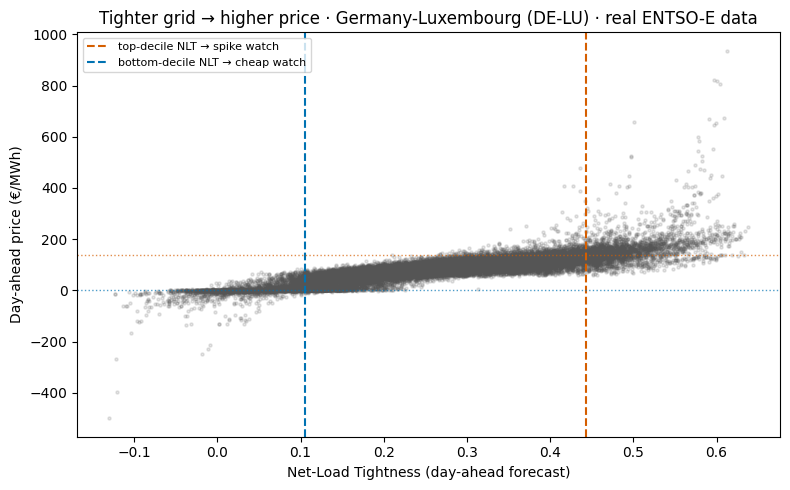

In [4]:
th = fit_thresholds(df["nlt"].to_numpy(), df["price"].to_numpy())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["nlt"], df["price"], s=5, alpha=0.15, color="#555")
ax.axvline(th["nlt_top"], color=SPIKE, ls="--", lw=1.5, label="top-decile NLT → spike watch")
ax.axvline(th["nlt_bottom"], color=CHEAP, ls="--", lw=1.5, label="bottom-decile NLT → cheap watch")
ax.axhline(th["spike_price"], color=SPIKE, ls=":", lw=1, alpha=0.7)
ax.axhline(C.NEG_PRICE_CEILING, color=CHEAP, ls=":", lw=1, alpha=0.7)
ax.set_xlabel("Net-Load Tightness (day-ahead forecast)")
ax.set_ylabel("Day-ahead price (€/MWh)")
ax.set_title(f"Tighter grid → higher price · {C.ZONE_LABEL} · {SOURCE}")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

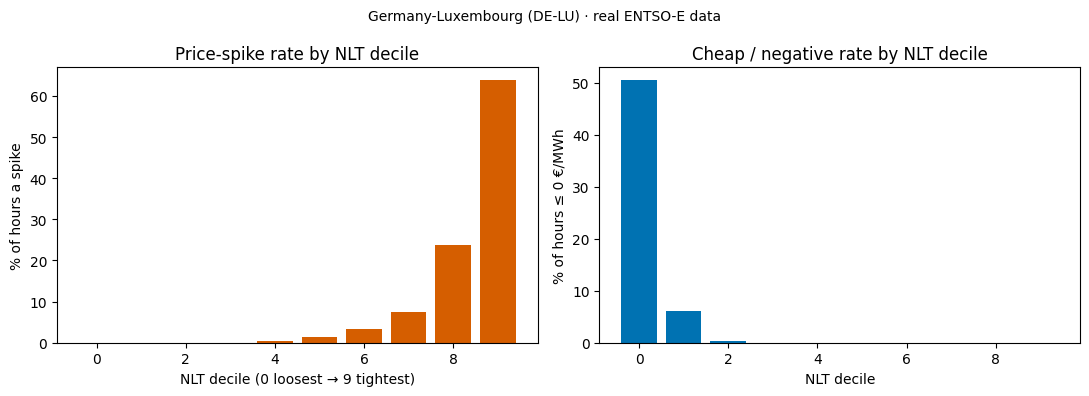

In [5]:
# Monotonicity check: spike rate and negative rate should climb / fall across NLT deciles.
d = df.dropna(subset=["nlt"]).copy()
d["decile"] = pd.qcut(d["nlt"], 10, labels=False, duplicates="drop")
d["is_spike"] = (d["price"] >= th["spike_price"]).astype(float)
d["is_neg"] = (d["price"] <= C.NEG_PRICE_CEILING).astype(float)
by = d.groupby("decile")[["is_spike", "is_neg"]].mean() * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(by.index, by["is_spike"], color=SPIKE)
a1.set_title("Price-spike rate by NLT decile"); a1.set_xlabel("NLT decile (0 loosest → 9 tightest)")
a1.set_ylabel("% of hours a spike")
a2.bar(by.index, by["is_neg"], color=CHEAP)
a2.set_title("Cheap / negative rate by NLT decile"); a2.set_xlabel("NLT decile")
a2.set_ylabel("% of hours ≤ 0 €/MWh")
fig.suptitle(f"{C.ZONE_LABEL} · {SOURCE}", fontsize=10)
fig.tight_layout(); plt.show()

## The forward view: which upcoming hours are flagged

Same signal, pointed at the most recent window, using thresholds fit only on the history
*before* it. In production this window is the next 7 days of published forecasts; here it's
the tail of the dataset as a stand-in.

In [6]:
HOURS = 168
hist, upcoming = df.iloc[:-HOURS], df.iloc[-HOURS:]
thL = fit_thresholds(hist["nlt"].to_numpy(), hist["price"].to_numpy())
sflag, cflag = apply_flags(upcoming, thL)
flags = ["🔺 spike-risk" if s else "🔻 cheap/neg" if c else "" for s, c in zip(sflag, cflag)]
live = upcoming[["timestamp", "nlt"]].assign(flag=flags)
live[live["flag"] != ""].reset_index(drop=True).head(30)

,timestamp,nlt,flag
0,2025-12-24 23:00:00,0.091287,🔻 cheap/neg
1,2025-12-25 00:00:00,0.083951,🔻 cheap/neg
2,2025-12-25 01:00:00,0.083610,🔻 cheap/neg
3,2025-12-25 02:00:00,0.085185,🔻 cheap/neg
4,2025-12-25 03:00:00,0.088757,🔻 cheap/neg
5,2025-12-25 04:00:00,0.092707,🔻 cheap/neg
6,2025-12-25 05:00:00,0.096720,🔻 cheap/neg


## What this doesn't do (so you can trust what it does)

- **Forecast-limited.** NLT rides on published load / wind / solar forecasts; when those miss, so does it. That's honest and it's the point — it's a *forward* signal, not hindsight.
- **`available_dispatchable` is v1.** It uses installed non-intermittent capacity. Subtracting real generation-unit outages (ENTSO-E unavailability) is the obvious next refinement.
- **One zone.** DE-LU only. The same schema extends to the other ENTSO-E bidding zones without a rewrite.
- **Not trading advice.** It's a computed data signal with a measured hit-rate, nothing more.

## If this is useful to you

I'm turning this into a **clean, maintained API** — normalised ENTSO-E data plus computed
signals like NLT — so you don't rebuild the pipe. Want it for your bidding zone, or a
different computed layer?

**→ Leave your email: `https://peaceful-chebakia-b8cb7b.netlify.app/`**  ·  code: `https://github.com/thomasgibson738-lab/de-lu-power-signal`

If it's not useful, tell me why — that's worth as much as a signup.